# Student-Habits-vs-Academic-Performance

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
df = pd.read_csv('../dataset/student_habits_performance.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

### About the dataset
The dataset is about students and their behaviour.

I am aiming to do some EDTA, train some models based on statemodels, univariant analysis, OUtlier treatement, bivariant analysis and Time inddependece.

In [60]:
# Looking out for null values
df.isna().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [70]:
df['parental_education_level'].unique()

array(['Master', 'High School', 'Bachelor', nan], dtype=object)

## I am having three options for parental_education_level nan values. 

1. I remove all the 91 such rows
2. I try to predict those values
3. Keep thbem as nan value after ohe

In [77]:
### lets go with the 1st option
df_p_na= df.dropna()
df_p_na.shape

(909, 16)

# Univariant Analysis

In [87]:
## we can observe the dataset is having age grp from 17 to 24 year old
vals = sorted(df['age'].unique())
vals

[17, 18, 19, 20, 21, 22, 23, 24]

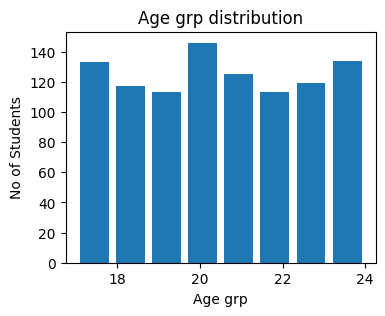

In [100]:
plt.figure(figsize=(4,3))
plt.hist(df['age'], bins=8, rwidth=0.8)
plt.xlabel("Age grp")
plt.ylabel("No of Students")
plt.title("Age grp distribution")
plt.show()

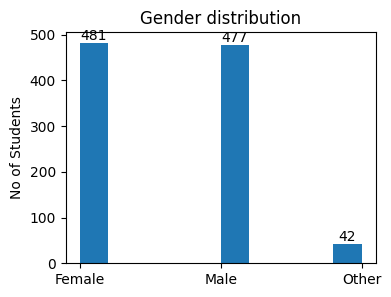

In [106]:
plt.figure(figsize=(4,3))
counts, bins, patches = plt.hist(df['gender'])

for count, bin_edge in zip(counts, bins[:-1]):
    if count > 0:
        plt.text(bin_edge + (bins[1] - bins[0]) / 2, count + 0.1, str(int(count)),
             ha='center', va='bottom')

plt.ylabel("No of Students")
plt.title("Gender distribution")
plt.show()

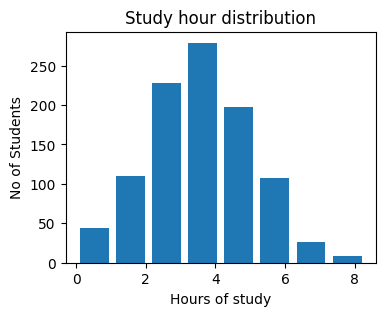

In [109]:
plt.figure(figsize=(4,3))
plt.hist(df['study_hours_per_day'], bins=8, rwidth=0.8)
plt.xlabel("Hours of study")
plt.ylabel("No of Students")
plt.title("Study hour distribution")
plt.show()


--- age ---
count    1000.0000
mean       20.4980
std         2.3081
min        17.0000
25%        18.7500
50%        20.0000
75%        23.0000
max        24.0000
Name: age, dtype: float64
Missing values: 0


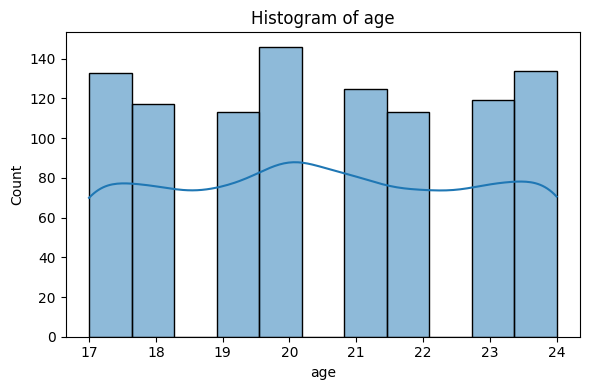


--- gender ---
count       1000
unique         3
top       Female
freq         481
Name: gender, dtype: object
Missing values: 0


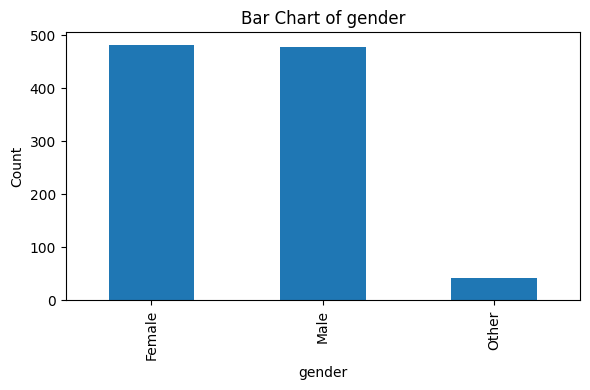


--- study_hours_per_day ---
count    1000.00000
mean        3.55010
std         1.46889
min         0.00000
25%         2.60000
50%         3.50000
75%         4.50000
max         8.30000
Name: study_hours_per_day, dtype: float64
Missing values: 0


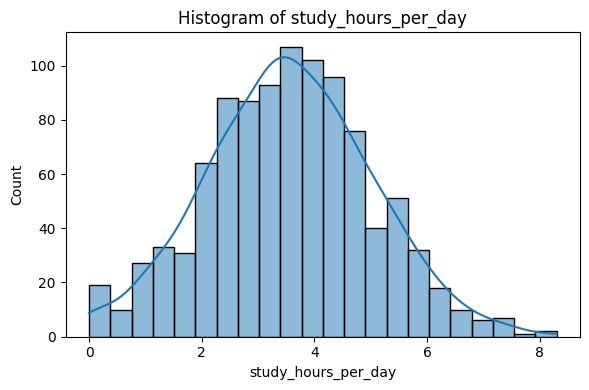


--- social_media_hours ---
count    1000.000000
mean        2.505500
std         1.172422
min         0.000000
25%         1.700000
50%         2.500000
75%         3.300000
max         7.200000
Name: social_media_hours, dtype: float64
Missing values: 0


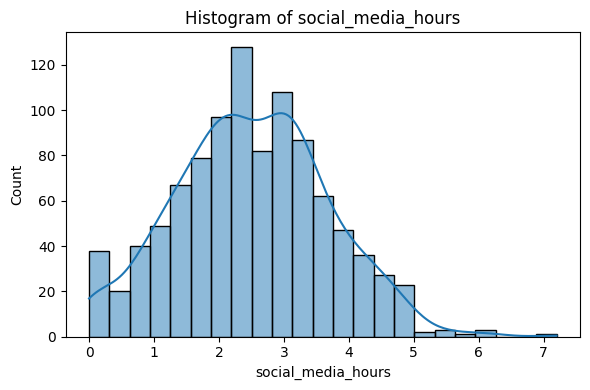


--- netflix_hours ---
count    1000.000000
mean        1.819700
std         1.075118
min         0.000000
25%         1.000000
50%         1.800000
75%         2.525000
max         5.400000
Name: netflix_hours, dtype: float64
Missing values: 0


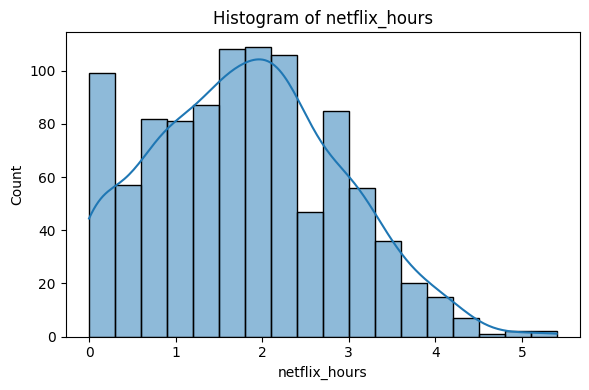


--- part_time_job ---
count     1000
unique       2
top         No
freq       785
Name: part_time_job, dtype: object
Missing values: 0


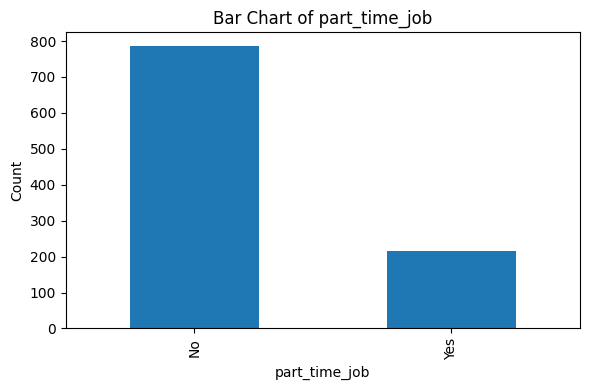


--- attendance_percentage ---
count    1000.000000
mean       84.131700
std         9.399246
min        56.000000
25%        78.000000
50%        84.400000
75%        91.025000
max       100.000000
Name: attendance_percentage, dtype: float64
Missing values: 0


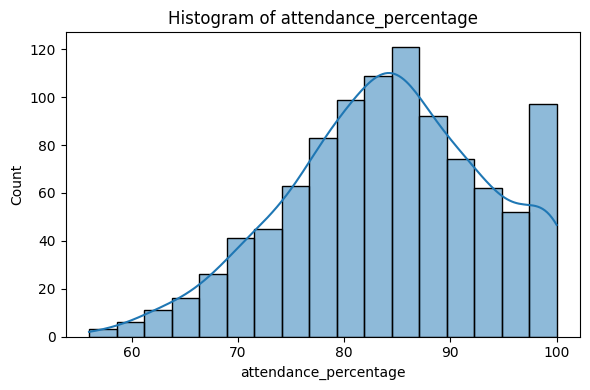


--- sleep_hours ---
count    1000.000000
mean        6.470100
std         1.226377
min         3.200000
25%         5.600000
50%         6.500000
75%         7.300000
max        10.000000
Name: sleep_hours, dtype: float64
Missing values: 0


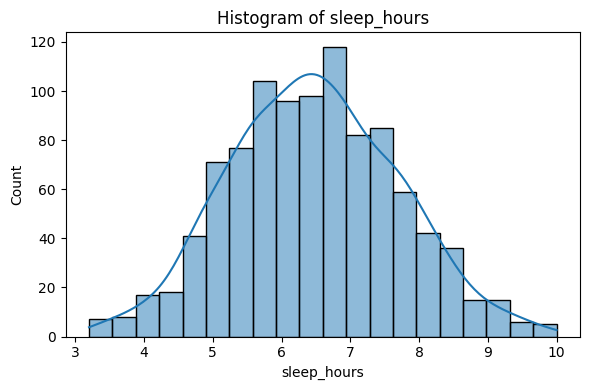


--- diet_quality ---
count     1000
unique       3
top       Fair
freq       437
Name: diet_quality, dtype: object
Missing values: 0


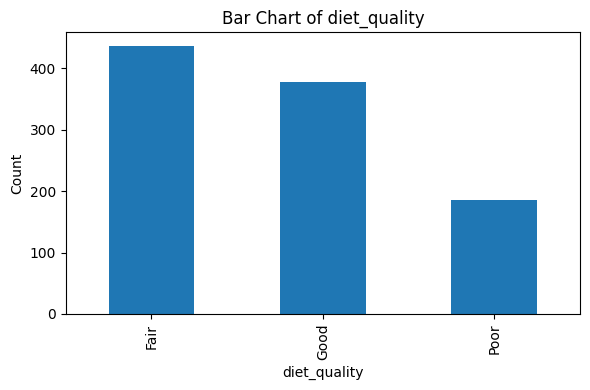


--- exercise_frequency ---
count    1000.000000
mean        3.042000
std         2.025423
min         0.000000
25%         1.000000
50%         3.000000
75%         5.000000
max         6.000000
Name: exercise_frequency, dtype: float64
Missing values: 0


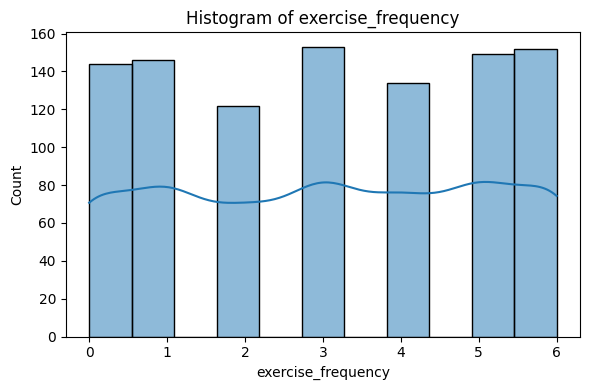


--- parental_education_level ---
count             909
unique              3
top       High School
freq              392
Name: parental_education_level, dtype: object
Missing values: 91


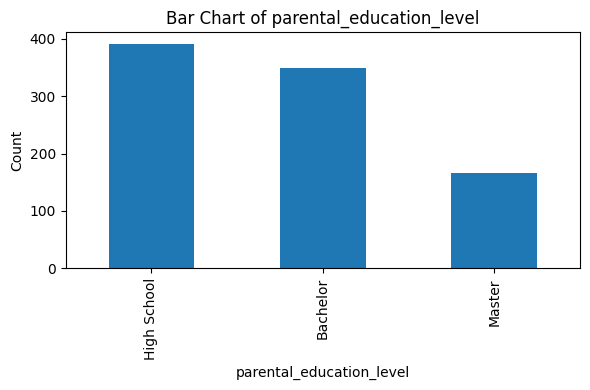


--- internet_quality ---
count     1000
unique       3
top       Good
freq       447
Name: internet_quality, dtype: object
Missing values: 0


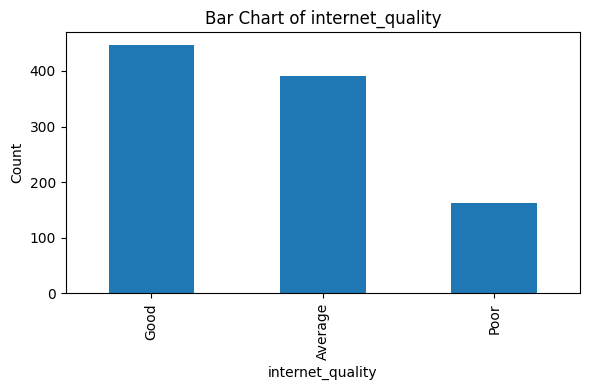


--- mental_health_rating ---
count    1000.000000
mean        5.438000
std         2.847501
min         1.000000
25%         3.000000
50%         5.000000
75%         8.000000
max        10.000000
Name: mental_health_rating, dtype: float64
Missing values: 0


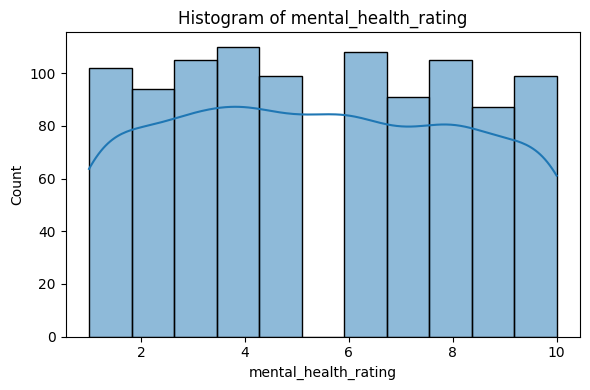


--- extracurricular_participation ---
count     1000
unique       2
top         No
freq       682
Name: extracurricular_participation, dtype: object
Missing values: 0


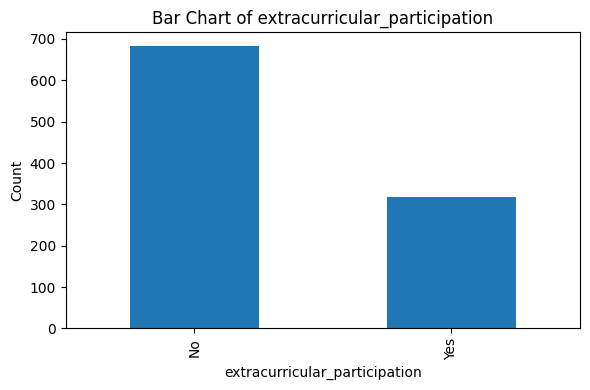


--- exam_score ---
count    1000.000000
mean       69.601500
std        16.888564
min        18.400000
25%        58.475000
50%        70.500000
75%        81.325000
max       100.000000
Name: exam_score, dtype: float64
Missing values: 0


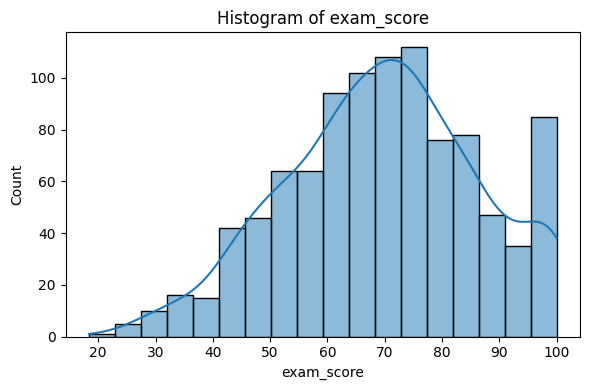

In [115]:
def univariate_analysis(df):
    for column in df.columns:
        print(f"\n--- {column} ---")
        print(df[column].describe())
        print("Missing values:", df[column].isnull().sum())
        
        plt.figure(figsize=(6, 4))
        
        if pd.api.types.is_numeric_dtype(df[column]):
            sns.histplot(df[column].dropna(), kde=True)
            plt.title(f"Histogram of {column}")
        else:
            df[column].value_counts().plot(kind='bar')
            plt.title(f"Bar Chart of {column}")
        
        plt.xlabel(column)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()
univariate_analysis(df.drop(columns=["student_id"], axis=0))

# Bivariant Analysis